The **Hamming weight** ($\text{HW}$) considers the truth table of an automaton running on a network topology. For each node, it counts the fraction of combinations of zeros and ones (possible state configs.) that will lead to $\phi(s,\rho) = 1$.

$$ 
\text{HW}(\mathcal{G}) = 
\frac{1}{|V|} \sum_{v_i \in \mathcal{V}} \text{HW}(k_i) = 
\sum_{k = 1}^{K} P(k|\mathcal{G}) \cdot \text{HW}(k)
$$

$$
\text{HW}(k) = 
\frac{1}{2^{k+1}} 
\sum_{s \in \{0, 1\}} \sum_{q = 0}^{k} 
\binom{k}{q} \phi\!\left(s, \frac{q}{k}\right) 
$$

Similarly we can define the **boolean sensitivity** (BS) of a network, which the degree-based equation is written in terms of _identity_ and _neighborhood_ sensitivities.

$$
\text{BS}(k) = 
\frac{1}{2^{k+1}} \sum_{s \in \{0, 1\}} \sum_{q = 0}^{k} 
\binom{k}{q} \bigl( \text{IS}(s, q, k) + \text{NS}(s, q, k) \bigr)
$$

$$
\text{IS}(s, q, k) = 
\phi\!\left(s, \frac{q}{k} \right) \oplus
\phi\!\left(s \oplus 1, \frac{q}{k} \right)
$$

$$
\text{NS}(s, q, k) = 
q\text{NS}^{-}(s, q, k) + 
(k - q)\text{NS}^{+}(s, q, k)
$$

$$
\text{NS}^{\pm}(s, q, k) = 
\phi\!\left(s, \frac{q}{k} \right) \oplus
\phi\!\left(s, \frac{q \pm 1}{k} \right)
$$

In order to avoid recalculating the binomial distribution for every network and transition rule, we can factorate the equations and separate the binomium from the degree distribution and the rule behaviour. Both HW and BS can be writen as follow, where $M$ is a measure, $u_q^k = 2^{-k}\binom{k}{q}$ is the normalized binomium distribution of $k$, and $z_q^k = \frac{1}{2} \sum_{s \in \{0, 1\}} f_m(\phi,s,q,k)$ is a function that considers how the density $\rho = \frac{q}{k}$ interacts with $\phi$ in the update criterion of state $s$.

$$ M(k) = \sum_{q = 0}^{k} u_q^k z_q^k = \mathbf{u}^k \cdot \mathbf{z}^k $$

By mapping each value $\frac{q}{K}$ to one of the $i$-th non-overlapping density intervals $\mathcal{H}_i^\alpha$, the vectors $\mathbf{u}, \mathbf{z}$ will have a fixed size regardless of the degree and $f_m$ could be pre-computed using the boolean vectors $\mathbf{x}, \mathbf{y}$ that represent $\phi$.

Let $u_i^{k \to \alpha} = \sum_q u_q^k \cdot h\!\left(i, \frac{q}{k}\right)$ be this mapping for the vector $\mathbf{u}$ and $z_i^{k \to \alpha}$ the equivalent for $\mathbf{z}$, where $h$ returns 1 if $q/k \in \mathcal{H}^\alpha_i$ and 0 otherwise. The equation
$$
\mathbf{u}^k \cdot \mathbf{z}^k =
\mathbf{u}^{k \to \alpha} \cdot \mathbf{z}^{k \to \alpha}
$$
is only valid when the value of $f_m$ for a given interval $i$ does not depend on the density, i.e. $f_m(\phi,s,q,k) = f_m(\phi,s) \;\forall i,k$, or when the mapping does not include more than one density value $\frac{q}{k}$ into a same interval $\mathcal{H}_i^\alpha$, which is satisfied while $k \le \alpha - 1$.

In [30]:
###########################################################################################

There are special cases where $f_m = f_m(\phi,s)$ regardless of the values of $k, \alpha$, allowing to write $M(\mathcal{G})$ in a short form. Let $\mathbf{p}^\mathcal{G} \in [0, 1]^K$ be the vector of degree distribution of a network, $p_k = P(k|\mathcal{G})$.

$$ M(\mathcal{G}) = {\mathbf{p}^\mathcal{G}}^\top \cdot \mathbf{U} \cdot \vec{f}_\text{HW}(\vec{x}, \vec{y})
$$

Both HW and BS are measures that consider the distribution of states in the neighborhood and how they interact with the transition function. Let's try to factorate them, separating the neighborhood influence from the rest.

Let $\mathbf{U} = [ u_{k,i} ] \in \{0; 1\}^{k_\text{max} \times \alpha}$ be the _potential sensitivity_ matrix, denoting how many arrangements of size $k$ neighbors exist in the $i$-th density interval.

$$
u_{k,i} = 
\frac{1}{2^k} \sum_{q=0}^{k} 
\binom{k}{q} \, f_R\!\left(i, \frac{q}{k}\right)
$$

$$
f_R\!\left(i, \frac{q}{k}\right) = 
\begin{cases}
    1 &\text{if}\; \frac{q}{k} \in R_i \\
    0 &\text{otherwise} \\
\end{cases}
$$

Let $\vec{p}_\mathcal{G} = [ p_k ] \in \{0; 1\}^{k_\text{max}}$ be the _degree probability_ vector, where $p_k = P(k|\mathcal{G})$. Considering the boolean vector notation of the transition function $\phi = (\vec{x}, \vec{y})$, we want to find functions $\vec{f}: [0; 1]^\alpha \times [0; 1]^\alpha  \mapsto \{0; 1\}^{\alpha}$ that satisfy

$$
\text{HW}(\mathcal{G}) = \vec{p}^\top_\mathcal{G} \cdot \mathbf{U} \cdot \vec{f}_\text{HW}(\vec{x}, \vec{y})
$$
$$
\text{BS}(\mathcal{G}) = \vec{p}^\top_\mathcal{G} \cdot \mathbf{U} \cdot \vec{f}_\text{BS}(\vec{x}, \vec{y})
$$

which reflects in the following generic shape.

$$
\vec{f} = 
\frac{1}{2} \sum_{s \in \{0; 1\}}
\bigl( \dots \bigr)
$$

In [1]:
# standard preamble for the Notebooks I use
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.automata import LLNA
from src.simulation import *
from src.rules import binary_indices
from src.analysis import hamming_weight, boolean_sens

from scipy.stats import binom
from scipy.special import comb

import seaborn as sns
sns.set_palette('Set2')

Let's build the _potential sensibility_ matrix $\mathbf{U} = \left[ \mathbf{u}^{k_1} \dots \mathbf{u}^{k_n} \right]^\top \in \{0, 1\}^{n \times \alpha}$ containing the discretized vectors for $n$ different node degrees.

Also, for the non-isomorphic LLNA rules $\phi \in \Phi^\alpha$ we have $h(i,\rho) = 1 \iff i = \min \{ \lfloor \alpha\rho \rfloor+1, \alpha \}$, $i = 1, \dots, \alpha$.

In [2]:
resolution = 9
degrees = np.array([1, 4, 7, 8, 12, 15, 50])

In [3]:
floor = lambda x: int(np.floor(x))
xor = lambda a, b: (a.astype(bool) ^ b.astype(bool)).astype(a.dtype)
interval_of = lambda res, rho: max(min(floor(res*rho), res-1), 0)

In [4]:
def potential_sensitivity(resolution:int, degrees:list):
    U = np.zeros((len(degrees), resolution))
    for j, k in enumerate(degrees):
        for q in range(k+1):
            qt = comb(k, q, exact=True)
            i = interval_of(resolution, q/k)
            U[j,i] += qt
        U[j,:] /= 2**k
    return U

U = potential_sensitivity(resolution, degrees)
print(U.shape, '= (|{k}|, alpha)')
U.round(3)

(7, 9) = (|{k}|, alpha)


array([[0.5  , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.5  ],
       [0.062, 0.   , 0.25 , 0.   , 0.375, 0.   , 0.25 , 0.   , 0.062],
       [0.008, 0.055, 0.164, 0.273, 0.   , 0.273, 0.164, 0.055, 0.008],
       [0.004, 0.031, 0.109, 0.219, 0.273, 0.219, 0.109, 0.031, 0.004],
       [0.003, 0.016, 0.054, 0.314, 0.226, 0.193, 0.175, 0.016, 0.003],
       [0.   , 0.017, 0.042, 0.244, 0.393, 0.153, 0.133, 0.017, 0.   ],
       [0.   , 0.   , 0.008, 0.232, 0.52 , 0.232, 0.008, 0.   , 0.   ]])

In [5]:
U.sum(1)

array([1., 1., 1., 1., 1., 1., 1.])

In [6]:
def increase_resolution(factor, *parts):
    for old_part in parts:
        res = len(old_part)
        new_part = np.zeros(res*factor)
        for i in range(res):
            new_part[ factor*i : factor*(i+1)] = old_part[i]
        yield new_part

## Hamming weight

Let's start considering $z$ as a function $[0,1] \to \{0,1\}$.

$$
f_\text{HW}(\phi,s,q,k) = 
\phi\!\left(s,\frac{q}{k}\right) 
$$

$$
\frac{1}{2}
\sum_{s \in \{0, 1\}} f_\text{HW}(\phi,s,q,k) = 
\frac{1}{2} \left(
\phi\!\left(0,\frac{q}{k}\right) + 
\phi\!\left(1,\frac{q}{k}\right) 
\right)
$$

$$ z(\rho) = \frac{1}{2} \bigl( \phi(0,\rho) + \phi(1, \rho) \bigr) $$

As the values $z^k_q$ are equivalent to applying the function $z$ in $\rho = q/k$, we can make the mapping $k \to \alpha$ by discretizing the functions $z, \phi$ to the resolution $\alpha$.

$$ \mathbf{z}^{k \to \alpha} = \frac{1}{2} ( \mathbf{x} + \mathbf{y} ) $$

Moreover, as $\mathbf{z}^{k \to \alpha}$ does not depend on the values of $q, k$, the calculation of the Hamming Weight for $\mathbf{k} = [k_1 \dots k_n]^\top$ can be simplified as follows.

$$
\text{HW}(\mathbf{k}) = 
\frac{1}{2} \mathbf{U} \cdot 
( \mathbf{x} + \mathbf{y} )
$$

In [7]:
resolution = 9
B_set = binary_indices(72)
S_set = binary_indices(12)

x = np.array([ float(i in B_set) for i in range(resolution) ])
y = np.array([ float(i in S_set) for i in range(resolution) ])

x, y

(array([0., 0., 0., 1., 0., 0., 1., 0., 0.]),
 array([0., 0., 1., 1., 0., 0., 0., 0., 0.]))

In [8]:
HW_direct = np.array([ hamming_weight(resolution, B_set, S_set, deg, iso=False) for deg in degrees ])
HW_direct.round(4)

array([0.    , 0.25  , 0.4375, 0.3281, 0.4283, 0.3319, 0.2399])

In [9]:
HW_factored = np.matmul(U, (x + y)/2)
HW_factored.round(4)

array([0.    , 0.25  , 0.4375, 0.3281, 0.4283, 0.3319, 0.2399])

## Identity sensitivity

The deduction is very similar to the one performed before. Let's start considering $z$ as a function $[0,1] \to \{0,1\}$.

$$
f_\text{IS}(\phi,s,q,k) = 
\phi\!\left(s,\frac{q}{k}\right) \oplus 
\phi\!\left(s \oplus 1,\frac{q}{k}\right) 
$$

$$
\frac{1}{2}
\sum_{s \in \{0, 1\}} f_\text{IS}(\phi,s,q,k) = 
2 \cdot \frac{1}{2} \left(
\phi\!\left(0,\frac{q}{k}\right) \oplus 
\phi\!\left(1,\frac{q}{k}\right) \right)
$$

$$ z(\rho) = \phi(0,\rho) \oplus \phi(1, \rho) $$

As the values $z^k_q$ are equivalent to applying the function $z$ in $\rho = q/k$, we can make the mapping $k \to \alpha$ by discretizing the functions $z, \phi$ to the resolution $\alpha$.

$$ \mathbf{z}^{k \to \alpha} = \mathbf{x} \oplus \mathbf{y} $$

Moreover, as $\mathbf{z}^{k \to \alpha}$ does not depend on the values of $q, k$, the calculation of the Identity Sensibility for $\mathbf{k} = [k_1 \dots k_n]^\top$ can be simplified as follows.

$$
\text{IS}(\mathbf{k}) = 
\mathbf{U} \cdot 
( \mathbf{x} \oplus \mathbf{y} )
$$

In [10]:
resolution = 9
B_set = binary_indices(2**resolution-1)
S_set = binary_indices(0)

x = np.array([ float(i in B_set) for i in range(resolution) ])
y = np.array([ float(i in S_set) for i in range(resolution) ])

x, y

(array([1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0.]))

In [11]:
IS_direct = np.array([ boolean_sens(resolution, B_set, S_set, deg, norm_degree=False, iso=False) for deg in degrees ])
IS_direct

array([1., 1., 1., 1., 1., 1., 1.])

In [12]:
#IS_factored = 1/(degrees + 1) * np.matmul(U, xor(x, y)) # use this if norm_degree=True
IS_factored = np.matmul(U, xor(x, y))
IS_factored

array([1., 1., 1., 1., 1., 1., 1.])

## Neighborhood sensitivity

The deduction is now slightly different, as the result of $f_\text{IS}$ in a same interval $\mathcal{H}_i^\alpha$ vary depending on $q, k$.

Let's start considering $z$ as a function $\mathbb{N}^* \times [0,1] \to \{0,1\}$.

$$ \Delta\phi(s,\rho, \Delta\rho) = \phi(s,\rho) \oplus \phi(s,\rho + \Delta\rho) $$

$$
f_\text{NS}(\phi,s,q,k) = 
q \Delta\phi\!\left( s,\frac{q}{k},\frac{-1}{k} \right) + 
(k - q) \Delta\phi\!\left( s,\frac{q}{k},\frac{+1}{k} \right)
$$

$$
\frac{1}{2}
\sum_{s \in \{0, 1\}} f_\text{IS}(\phi,s,q,k) = 
\frac{1}{2} \left(
    q \sum_s \Delta\phi\!\left( s,\frac{q}{k},\frac{-1}{k} \right) + 
    (k - q) \sum_s \Delta\phi\!\left( s,\frac{q}{k},\frac{+1}{k} \right)
\right)
$$

$$
z(k, \rho) = \frac{k}{2} \Biggl(
    \rho       \sum_s \Bigl( \phi(s,\rho) \oplus \phi(s,\rho - 1/k) \Bigr) + 
    (1 - \rho) \sum_s \Bigl( \phi(s,\rho) \oplus \phi(s,\rho + 1/k) \Bigr)
\Biggr)
$$

Note that even after making the density $\rho$ appear, it is impossible to remove the node degree $k$ from the formula, meaning that the value of $\mathbf{z}^{k \to \alpha}$ is strictly dependent on $k$.

Returning to the formula in terms of $q, k$ and defining $ i\pm = \sum_{i=1}^\alpha i \cdot h\!\left(i, \frac{q \pm 1}{k} \right) $, we have:

$$
z^{k \to \alpha}_i = \frac{1}{2} \sum_{q=0}^k 
h\!\left(i, \frac{q}{k} \right) \cdot
\Biggl(
    q \Bigl( (x_i \oplus x_{i-}) + (y_i \oplus y_{i-}) \Bigr) + 
(k-q) \Bigl( (x_i \oplus x_{i+}) + (y_i \oplus y_{i+}) \Bigr)
\Biggr)
\;,\; k \le \alpha
$$

$$
\text{NS}(\mathbf{k}) = 
\left[
\mathbf{u}^{k_i \to \alpha} \cdot 
\mathbf{z}^{k_i \to \alpha}
\right]^\top
$$

In [30]:
resolution = 9
B_set = binary_indices(sum([ 2**i for i in range(0, resolution, 2) ]))
S_set = B_set

x = np.array([ float(i in B_set) for i in range(resolution) ])
y = np.array([ float(i in S_set) for i in range(resolution) ])

x, y

(array([1., 0., 1., 0., 1., 0., 1., 0., 1.]),
 array([1., 0., 1., 0., 1., 0., 1., 0., 1.]))

In [31]:
NS_direct = np.array([ boolean_sens(resolution, B_set, S_set, deg, norm_degree=False, iso=False) for deg in degrees ])
NS_direct.round(4)

array([0.    , 0.    , 4.8125, 8.    , 9.0879, 8.9401, 9.4284])

In [39]:
def f_ns(x, y, degrees, correction=True):
    resolution = len(x)
    Z = np.zeros((len(degrees), resolution))
    C = np.zeros((len(degrees), resolution))

    for ki, k in enumerate(degrees):
        for q in range(0, k+1):
            i_curr = interval_of(resolution, q/k) #min(floor(resolution*q/k), resolution-1)
            i_next = interval_of(resolution, (q+1)/k) #min(floor(resolution*(q+1)/k), resolution-1)
            i_prev = interval_of(resolution, (q-1)/k) #max(floor(resolution*(q-1)/k), 0)

            Z[ki, i_curr] += (
                ( xor(x[i_curr], x[i_prev]) + xor(y[i_curr], y[i_prev]) ) * q +
                ( xor(x[i_curr], x[i_next]) + xor(y[i_curr], y[i_next]) ) * (k-q)
            ) / 2
            C[ki, i_curr] += 1
        mask = (C[ki, :] > 1)
        C[ki, mask] = 1/C[ki, mask] + int(correction)/(k+resolution) # correction term for k >= resolution
    return (Z * C)

In [40]:
# is precise for: k <= resolution-1
# is a good approx. for at least: (resolution-1) < k <= (resolution-1)^2
U = potential_sensitivity(resolution, degrees)
Z = f_ns(x, y, degrees)
NS_factored = (U * Z).sum(1) # equiv to: np.matmul(U, Z.T).diagonal()

degrees, NS_direct.round(4), NS_factored.round(4) # results for R=9 (it loses prec. when k = 12, 15, 50)

(array([ 1,  4,  7,  8, 12, 15, 50]),
 array([0.    , 0.    , 4.8125, 8.    , 9.0879, 8.9401, 9.4284]),
 array([0.    , 0.    , 4.8125, 8.    , 9.0411, 9.0251, 9.1819]))

In [41]:
Z.round(2)

array([[ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 7.  ,  7.  ,  7.  ,  3.  ,  0.  ,  3.  ,  7.  ,  7.  ,  7.  ],
       [ 8.  ,  8.  ,  8.  ,  8.  ,  8.  ,  8.  ,  8.  ,  8.  ,  8.  ],
       [ 6.02, 12.  , 12.  ,  6.02, 12.  , 12.  ,  6.02, 12.  ,  6.02],
       [ 7.58,  7.58, 15.  ,  7.58,  7.58, 15.  ,  7.58,  7.58,  7.58],
       [ 8.26,  8.26,  9.98,  8.26,  9.98,  8.26,  9.98,  8.26,  8.26]])

In [42]:
# increasing the resolution improves the precision range
U = potential_sensitivity(3*resolution, degrees)
Z = f_ns(*increase_resolution(3, x, y), degrees)
NS_factored = (U * Z).sum(1)

degrees, NS_direct.round(4), NS_factored.round(4) # results for R=27 (it loses prec. only for k = 50)

(array([ 1,  4,  7,  8, 12, 15, 50]),
 array([0.    , 0.    , 4.8125, 8.    , 9.0879, 8.9401, 9.4284]),
 array([0.    , 0.    , 4.8125, 8.    , 9.0879, 8.9401, 9.453 ]))

## Boolean sensitivity

In [22]:
resolution = 9
B_set = binary_indices(72)
S_set = binary_indices(12)

factor = 4
x, y = increase_resolution(
    factor, 
    np.array([ float(i in B_set) for i in range(resolution) ]),
    np.array([ float(i in S_set) for i in range(resolution) ])
)
U = potential_sensitivity(factor*resolution, degrees)

In [23]:
BS_direct = np.array([ boolean_sens(resolution, B_set, S_set, deg, norm_degree=False, iso=False) for deg in degrees ])
BS_direct.round(4)

array([0.    , 2.5   , 4.8125, 4.1562, 4.7078, 4.6322, 4.7295])

In [24]:
Z = f_ns(x, y, degrees)
BS_factored = np.matmul(U, xor(x, y)) + (U * Z).sum(1)
BS_factored.round(4)

array([0.    , 2.5   , 4.8125, 4.1562, 4.7078, 4.6322, 4.5746])

# Dump: precision check for NS approximation

In [25]:
degs = np.arange(0, 71)

resolution = 6
B_set = binary_indices(sum([ 2**i for i in range(0, resolution, 2) ]))
S_set = B_set

x = np.array([ float(i in B_set) for i in range(resolution) ])
y = np.array([ float(i in S_set) for i in range(resolution) ])

In [26]:
res1 = {}
v = {}
n = {}
for k in degs:
    ns = 0
    v[k] = np.zeros(k+1)
    n[k] = np.zeros(k+1)
    for q in range(0, k+1):
        i_curr = min(floor(resolution*q/k), resolution-1) if k else 0
        i_next = min(floor(resolution*(q+1)/k), resolution-1) if k else 0
        i_prev = max(floor(resolution*(q-1)/k), 0) if k else 0
        
        v[k][q] = comb(k, q, exact=True)# / 2**k
        n[k][q] = (
            ( xor(x[i_curr], x[i_next]) + xor(y[i_curr], y[i_next]) ) * (k-q) +
            ( xor(x[i_curr], x[i_prev]) + xor(y[i_curr], y[i_prev]) ) * q
        ) / 2
    v[k] /= v[k].sum()
    res1[k] = sum(v[k] * n[k])
res1 = np.array(list(res1.values()))

In [27]:
res2 = {}
u = {}
f = {}
c = {}
for k in degs:
    ns = 0
    u[k] = np.zeros(resolution)
    f[k] = np.zeros(resolution)
    c[k] = np.zeros(resolution)
    for q in range(0, k+1):
        i_curr = min(floor(resolution*q/k), resolution-1) if k else 0
        i_next = min(floor(resolution*(q+1)/k), resolution-1) if k else 0
        i_prev = max(floor(resolution*(q-1)/k), 0) if k else 0
        
        u[k][i_curr] += comb(k, q, exact=True)
        f[k][i_curr] += (
            ( xor(x[i_curr], x[i_next]) + xor(y[i_curr], y[i_next]) ) * (k-q) +
            ( xor(x[i_curr], x[i_prev]) + xor(y[i_curr], y[i_prev]) ) * q
        ) / 2
        c[k][i_curr] += 1
    for i, value in enumerate(c[k]):
        if value > 1:
            c[k][i] = 1/value + 1/(k+resolution)
    u[k] /= u[k].sum()
    #res2[k] = min(sum(u[k] * f[k]), resolution+1)
    res2[k] = sum(u[k] * f[k] * c[k])
res2 = np.array(list(res2.values()))

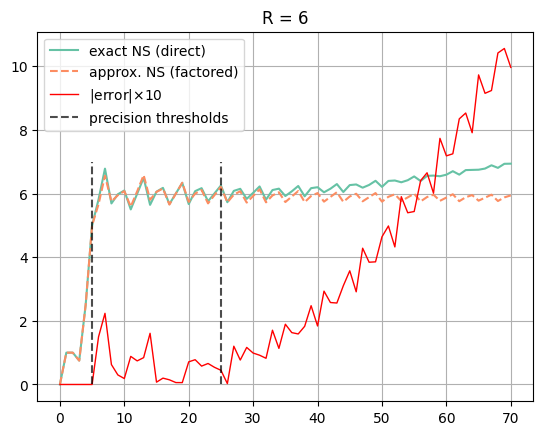

In [28]:
plt.plot(degs, res1, label='exact NS (direct)')
plt.plot(degs, res2, '--', label='approx. NS (factored)')
plt.plot(degs, np.abs(res1 - res2)*10, color='r', lw=1, label='|error|$\\times$10')
#plt.plot(degs, [ ck.sum() for ck in c.values() ], label='sum of counts')
plt.vlines([resolution-1, (resolution-1)**2], ymin=0, ymax=resolution+1, 
           ls='--', color='black', alpha=0.7, label='precision thresholds')
plt.title(f'R = {resolution}')
plt.legend()
plt.grid()

In [29]:
resolution, degs[resolution-1:resolution+1], (res1 - res2)[resolution-1:resolution+1]

(6, array([5, 6]), array([0.        , 0.14973958]))

## Dump: weird approximation of NS (abandoned trial)

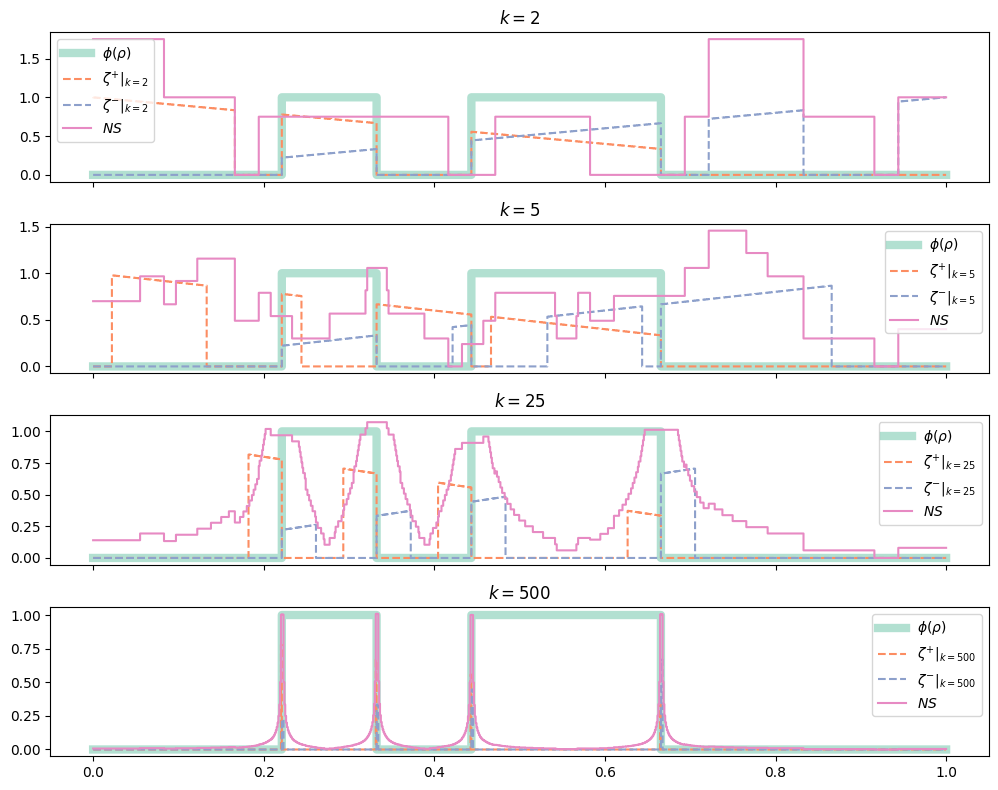

In [33]:
rho = np.linspace(0, 1, 1000)
is_in = lambda x, i, alpha: (x >= i/alpha) * (x < (i+1)/alpha)
phi = lambda x: is_in(x,2,9) + is_in(x,4,9) + is_in(x,5,9)
zeta_p = lambda x, k: (1-x) * (phi(x) ^ phi(x + 1/k))
zeta_n = lambda x, k: (x  ) * (phi(x) ^ phi(x - 1/k))
zeta_m = lambda x, k: zeta_p(x - 0.5/k, k) + zeta_n(x + 0.5/k, k)
zeta = lambda x, k_max: sum([ zeta_m(rho, k) for k in range(1, k_max+1) ]) / k_max
cprob = lambda k: np.array([ comb(k, i) for i in range (0, k+1)]) / 2**k

fig, axes = plt.subplots(4, 1, figsize=(10, 2*4), sharex=True)

for ax, k in zip(axes, [2, 5, 25, 500]):
    #ck = cprob(k)
    ax.set(title=f'$k = {k}$')
    
    ax.step(rho, phi(rho), lw=6, label='$\\phi(\\rho)$', alpha=0.5)
    ax.step(rho, zeta_p(rho, k), '--', label=f'$\\zeta^{{+}}|_{{k={k}}}$')
    ax.step(rho, zeta_n(rho, k), '--', label=f'$\\zeta^{{-}}|_{{k={k}}}$')
    #ax.step(rho, zeta_m(rho, k), label=f'$\\tilde{{\\zeta}}|_{{k={k}}}$')
    ax.step(rho, zeta(rho, k), label=f'$NS$')
    #plt.plot(rho, rho, 'k--')
    ax.legend()
plt.tight_layout()
plt.show()

In [38]:
[ zeta_m(rho, k).sum() for k in [2, 5, 100, 1000, 100000] ]

[958.5, 532.8, 36.36, 4.004, 4.00004]

In [39]:
[ zeta(rho, k).sum() for k in [2, 5, 100, 1000, 100000] ]

[813.25, 661.26, 151.24380275403158, 23.86342645001549, 4.198818451510889]